In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
data=pd.read_csv('electricityConsumptionAndProductioction.csv')

In [4]:
data.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [5]:
data['DateTime']=pd.to_datetime(data['DateTime'])

In [6]:
data.set_index('DateTime',inplace=True)

In [7]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [8]:
import matplotlib.pyplot as plt

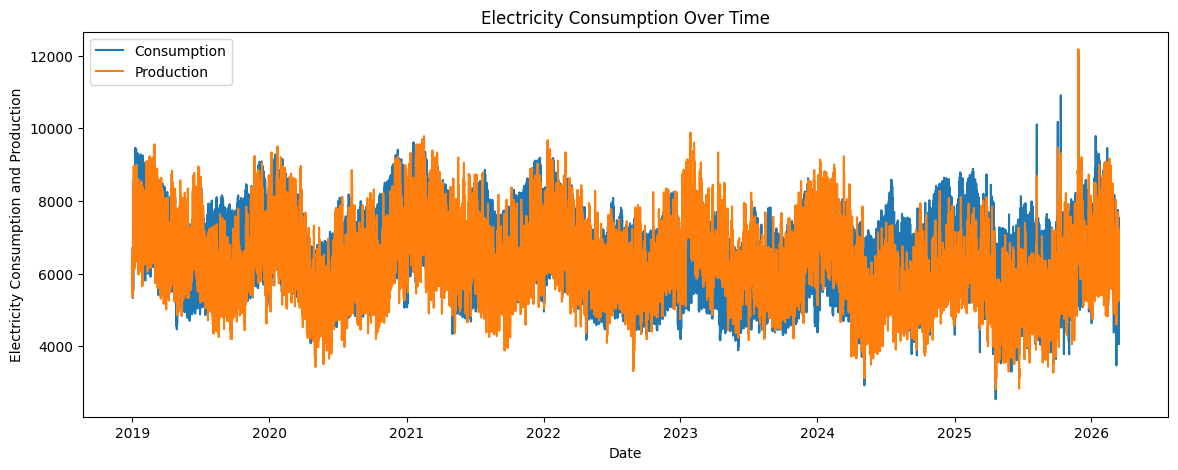

In [9]:
plt.figure(figsize=(14,5))
plt.plot(data.index,data['Consumption'],label='Consumption')
plt.plot(data.index,data['Production'],label='Production')
plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()

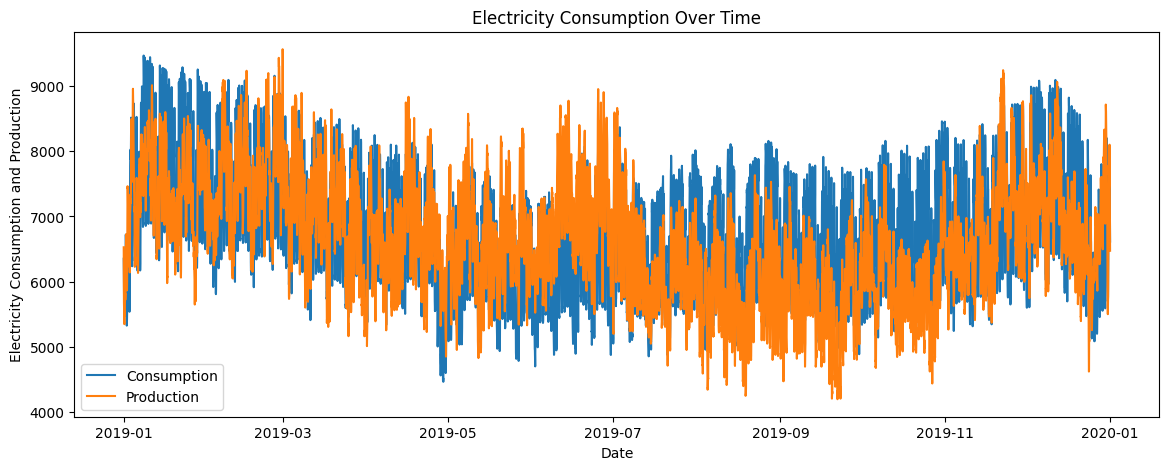

In [10]:
time='01-01-2020'
data[data.index<time]['Consumption']
plt.figure(figsize=(14,5))
plt.plot(data.index[data.index<time],data[data.index<time]['Consumption'],label='Consumption')
plt.plot(data.index[data.index<time],data[data.index<time]['Production'],label='Production')
plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()

In [11]:
data['hour']=data.index.hour

In [12]:
data['weekdays']=data.index.dayofweek

In [13]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays
DateTime,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1


In [14]:
data['quarter']=data.index.quarter

In [15]:
data['month']=data.index.month

In [16]:
data['year']=data.index.year

In [17]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,quarter,month,year
DateTime,,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1,1,1,2019
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1,1,1,2019
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1,1,1,2019
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1,1,1,2019
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,1,1,2019


In [57]:
data.hour

DateTime
2019-01-01 00:00:00     0
2019-01-01 01:00:00     1
2019-01-01 02:00:00     2
2019-01-01 03:00:00     3
2019-01-01 04:00:00     4
                       ..
2026-03-14 19:00:00    19
2026-03-14 20:00:00    20
2026-03-14 21:00:00    21
2026-03-14 22:00:00    22
2026-03-14 23:00:00    23
Name: hour, Length: 62810, dtype: int32

In [54]:
data["HourOfWeek"] = (
    data.index.dayofweek * 24
    + data.index.hour
)


In [58]:
data['hr_sin']=np.sin(2*np.pi*data.hour/24)
data['hr_cos']=np.cos(2*np.pi*data.hour/24)

In [60]:
for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
    data[f"target_lag_{lag}"] = data["Consumption"].shift(lag)

In [61]:
data["rolling_3"] = (
    data["Consumption"].shift(1).rolling(3).mean()
)

data["rolling_6"] = (
    data["Consumption"].shift(1).rolling(6).mean()
)

data["rolling_12"] = (
    data["Consumption"].shift(1).rolling(12).mean()
)

data["rolling_24"] = (
    data["Consumption"].shift(1).rolling(24).mean()
)

data["rolling_24_std"] = (
    data["Consumption"].shift(1).rolling(24).std()
)

In [68]:
data['dow_sin']=np.sin(2*np.pi*data.weekdays/7)
data['dow_cos']=np.cos(2*np.pi*data.weekdays/7)

In [69]:
data['month_sin']=np.sin(2*np.pi*data.month/7)
data['month_cos']=np.cos(2*np.pi*data.month/7)

In [74]:
data.drop('dow',inplace=True,axis=1)

In [75]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,...,NaN,6113.666667,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,...,NaN,5890.333333,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349


In [77]:
data.columns

Index(['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric',
       'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'hour', 'weekdays',
       'quarter', 'month', 'year', 'HourOfWeek', 'hr_sin', 'hr_cos',
       'target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_6',
       'target_lag_12', 'target_lag_24', 'target_lag_48', 'target_lag_72',
       'rolling_3', 'rolling_6', 'rolling_12', 'rolling_24', 'rolling_24_std',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
      dtype='object')

<Axes: xlabel='month', ylabel='Consumption'>

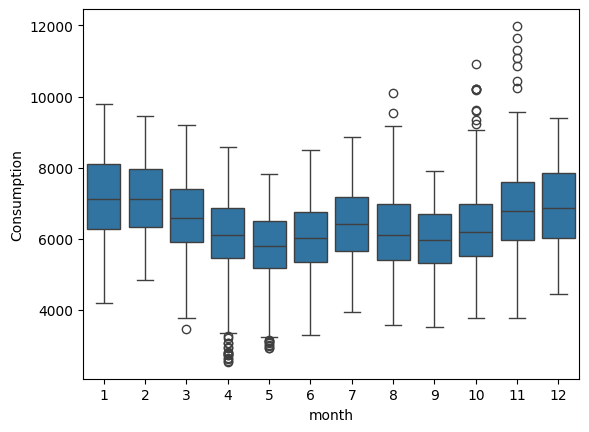

In [18]:
import seaborn as sns
sns.boxplot(data=data,x='month',y='Consumption')

In [19]:
data['month'].value_counts()

month
1     5939
3     5524
2     5281
10    5215
8     5196
7     5189
5     5180
12    5177
4     5038
6     5035
9     5026
11    5010
Name: count, dtype: int64

In [20]:
data['year'].value_counts()

year
2020    8785
2019    8761
2021    8761
2022    8761
2023    8760
2024    8640
2025    8590
2026    1752
Name: count, dtype: int64

In [21]:
data.columns

Index(['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric',
       'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'hour', 'weekdays',
       'quarter', 'month', 'year'],
      dtype='object')

In [22]:
target=data['Consumption']

In [78]:
data.iloc[:,0]

DateTime
2019-01-01 00:00:00    6352
2019-01-01 01:00:00    6116
2019-01-01 02:00:00    5873
2019-01-01 03:00:00    5682
2019-01-01 04:00:00    5557
                       ... 
2026-03-14 19:00:00    7132
2026-03-14 20:00:00    7027
2026-03-14 21:00:00    6615
2026-03-14 22:00:00    6063
2026-03-14 23:00:00    5712
Name: Consumption, Length: 62810, dtype: int64

In [79]:
data.iloc[:,1:]

,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6527,1395,79,1383,1896,1744,0,30,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.623490,0.781831,0.623490
2019-01-01 01:00:00,5701,1393,96,1112,1429,1641,0,30,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.623490,0.781831,0.623490
2019-01-01 02:00:00,5676,1393,142,1030,1465,1616,0,30,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.623490,0.781831,0.623490
2019-01-01 03:00:00,5603,1397,191,972,1455,1558,0,30,3,1,...,NaN,6113.666667,NaN,NaN,NaN,NaN,0.781831,0.623490,0.781831,0.623490
2019-01-01 04:00:00,5454,1393,159,960,1454,1458,0,30,4,1,...,NaN,5890.333333,NaN,NaN,NaN,NaN,0.781831,0.623490,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 19:00:00,6937,1339,699,2560,1590,598,0,59,19,5,...,7745.0,5969.000000,5121.000000,5036.083333,5569.541667,960.407431,-0.974928,-0.222521,0.433884,-0.900969
2026-03-14 20:00:00,6827,1339,744,2538,1571,579,0,58,20,5,...,7575.0,6614.000000,5633.833333,5157.333333,5552.000000,925.827010,-0.974928,-0.222521,0.433884,-0.900969
2026-03-14 21:00:00,6612,1341,778,2291,1569,578,0,60,21,5,...,7186.0,6945.333333,6106.500000,5289.083333,5535.500000,894.014639,-0.974928,-0.222521,0.433884,-0.900969


In [80]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,...,NaN,6113.666667,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,...,NaN,5890.333333,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349


In [81]:
weekly_pattern = data.groupby("HourOfWeek")["Consumption"].mean()

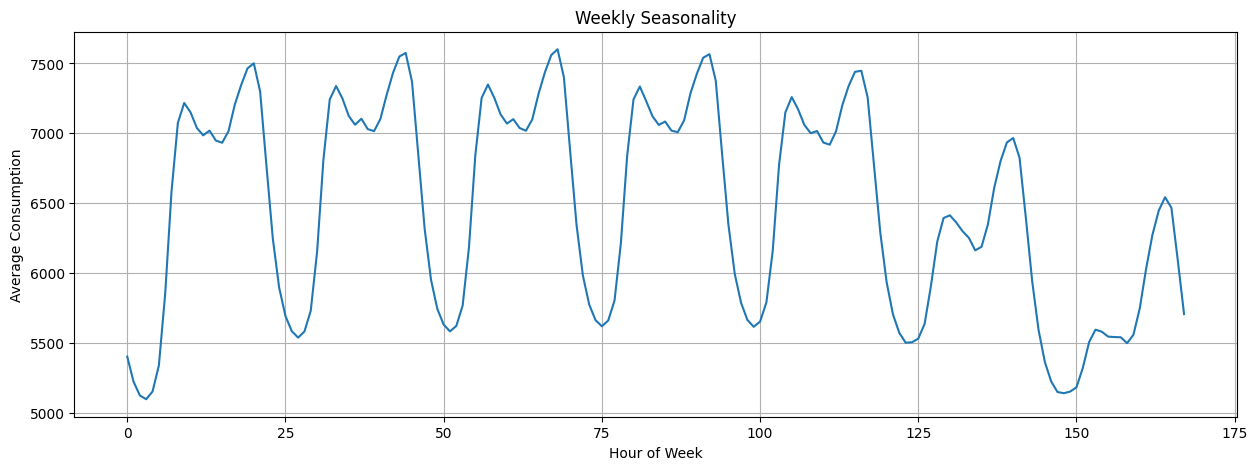

In [82]:
plt.figure(figsize=(15, 5))

plt.plot(weekly_pattern.index,weekly_pattern.values)

plt.xlabel("Hour of Week")
plt.ylabel("Average Consumption")
plt.title("Weekly Seasonality")

plt.grid()

plt.show()

In [83]:
data.index.year.value_counts()

DateTime
2020    8785
2019    8761
2021    8761
2022    8761
2023    8760
2024    8640
2025    8590
2026    1752
Name: count, dtype: int64

In [84]:
test=data[data.index.year>2025]
train=data[data.index.year<=2025]

In [85]:
test.index.year.value_counts()

DateTime
2026    1752
Name: count, dtype: int64

In [86]:
train.index.year.value_counts()

DateTime
2020    8785
2019    8761
2021    8761
2022    8761
2023    8760
2024    8640
2025    8590
Name: count, dtype: int64

In [87]:
target=data.iloc[:,0]

In [88]:
target

DateTime
2019-01-01 00:00:00    6352
2019-01-01 01:00:00    6116
2019-01-01 02:00:00    5873
2019-01-01 03:00:00    5682
2019-01-01 04:00:00    5557
                       ... 
2026-03-14 19:00:00    7132
2026-03-14 20:00:00    7027
2026-03-14 21:00:00    6615
2026-03-14 22:00:00    6063
2026-03-14 23:00:00    5712
Name: Consumption, Length: 62810, dtype: int64

In [89]:
df=data.iloc[:,1:]

In [90]:
df.head()

,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6527,1395,79,1383,1896,1744,0,30,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 01:00:00,5701,1393,96,1112,1429,1641,0,30,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 02:00:00,5676,1393,142,1030,1465,1616,0,30,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 03:00:00,5603,1397,191,972,1455,1558,0,30,3,1,...,NaN,6113.666667,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 04:00:00,5454,1393,159,960,1454,1458,0,30,4,1,...,NaN,5890.333333,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349


In [91]:
from sklearn.model_selection import train_test_split

In [92]:
x_train=train.iloc[:,1:]

In [93]:
y_train=train.iloc[:,0]

In [94]:
x_test=test.iloc[:,1:]
y_test=test.iloc[:,0]

In [95]:
x_train.head()

,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6527,1395,79,1383,1896,1744,0,30,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 01:00:00,5701,1393,96,1112,1429,1641,0,30,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 02:00:00,5676,1393,142,1030,1465,1616,0,30,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 03:00:00,5603,1397,191,972,1455,1558,0,30,3,1,...,NaN,6113.666667,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349
2019-01-01 04:00:00,5454,1393,159,960,1454,1458,0,30,4,1,...,NaN,5890.333333,NaN,NaN,NaN,NaN,0.781831,0.62349,0.781831,0.62349


In [96]:
y_train.head()

DateTime
2019-01-01 00:00:00    6352
2019-01-01 01:00:00    6116
2019-01-01 02:00:00    5873
2019-01-01 03:00:00    5682
2019-01-01 04:00:00    5557
Name: Consumption, dtype: int64

In [97]:
x_test

,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,...,target_lag_72,rolling_3,rolling_6,rolling_12,rolling_24,rolling_24_std,dow_sin,dow_cos,month_sin,month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,5956,1336,632,1303,1877,755,0,50,0,3,...,5534.0,6478.666667,6986.166667,6917.083333,6412.416667,713.128863,0.433884,-0.900969,0.781831,0.623490
2026-01-01 01:00:00,5240,1333,401,955,1875,596,0,47,1,3,...,5403.0,6175.000000,6682.666667,6889.416667,6410.625000,714.401897,0.433884,-0.900969,0.781831,0.623490
2026-01-01 02:00:00,5129,1338,362,942,1867,571,0,48,2,3,...,5254.0,5906.666667,6372.500000,6842.333333,6406.291667,718.828000,0.433884,-0.900969,0.781831,0.623490
2026-01-01 03:00:00,4987,1339,271,887,1857,584,0,49,3,3,...,5184.0,5678.000000,6078.333333,6743.833333,6404.125000,721.666327,0.433884,-0.900969,0.781831,0.623490
2026-01-01 04:00:00,4949,1335,138,967,1875,585,0,48,4,3,...,5244.0,5488.333333,5831.666667,6610.166667,6401.416667,725.709183,0.433884,-0.900969,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 19:00:00,6937,1339,699,2560,1590,598,0,59,19,5,...,7745.0,5969.000000,5121.000000,5036.083333,5569.541667,960.407431,-0.974928,-0.222521,0.433884,-0.900969
2026-03-14 20:00:00,6827,1339,744,2538,1571,579,0,58,20,5,...,7575.0,6614.000000,5633.833333,5157.333333,5552.000000,925.827010,-0.974928,-0.222521,0.433884,-0.900969
2026-03-14 21:00:00,6612,1341,778,2291,1569,578,0,60,21,5,...,7186.0,6945.333333,6106.500000,5289.083333,5535.500000,894.014639,-0.974928,-0.222521,0.433884,-0.900969


In [98]:
y_test

DateTime
2026-01-01 00:00:00    5904
2026-01-01 01:00:00    5655
2026-01-01 02:00:00    5475
2026-01-01 03:00:00    5335
2026-01-01 04:00:00    5278
                       ... 
2026-03-14 19:00:00    7132
2026-03-14 20:00:00    7027
2026-03-14 21:00:00    6615
2026-03-14 22:00:00    6063
2026-03-14 23:00:00    5712
Name: Consumption, Length: 1752, dtype: int64

In [99]:
from xgboost import XGBRegressor

In [100]:
model1 = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

In [101]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [102]:
param_grid = {
    "n_estimators": [200, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.5, 1],#It determines how much improvement a split must provide before XGBoost makes that split.
    "reg_alpha": [0, 0.01, 0.1, 1],#L1 regularization encourages some model weights to become exactly or approximately zero.
    "reg_lambda": [0.1, 1, 5, 10] #L2 Regularization 
}

tscv = TimeSeriesSplit(n_splits=5)


In [103]:
random_search = RandomizedSearchCV(
    estimator=model1,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [104]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [105]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
-128.66253662109375


In [106]:
from xgboost import XGBRegressor

model1 = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,

    subsample=1.0,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=1200,
    min_child_weight=5,
    max_depth=5,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=1.0
)

In [107]:
model1.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [108]:
print(model1.feature_importances_)
print(model1.feature_names_in_)

[1.7710826e-03 1.0969198e-03 3.8156853e-04 8.7541062e-04 7.4643746e-04
 1.4962740e-03 4.8193638e-03 3.4418592e-04 6.1157928e-03 4.0502208e-03
 1.1755398e-03 1.6062486e-03 2.2306619e-03 7.5303349e-03 1.6743997e-02
 7.6660499e-02 8.2738465e-01 3.3670478e-03 1.2276922e-02 1.7378747e-03
 2.1696060e-03 1.2084455e-02 3.7217003e-04 1.2811356e-03 6.5470551e-04
 1.7120877e-03 1.4206775e-03 3.3708399e-03 4.6138221e-04 3.7670447e-04
 2.6761458e-04 1.0982313e-03 2.3193955e-03]
['Production' 'Nuclear' 'Wind' 'Hydroelectric' 'Oil and Gas' 'Coal'
 'Solar' 'Biomass' 'hour' 'weekdays' 'quarter' 'month' 'year' 'HourOfWeek'
 'hr_sin' 'hr_cos' 'target_lag_1' 'target_lag_2' 'target_lag_3'
 'target_lag_6' 'target_lag_12' 'target_lag_24' 'target_lag_48'
 'target_lag_72' 'rolling_3' 'rolling_6' 'rolling_12' 'rolling_24'
 'rolling_24_std' 'dow_sin' 'dow_cos' 'month_sin' 'month_cos']


In [109]:

y_pred=model1.predict(x_test)

In [115]:
y_pred

array([5854.7705, 5671.0205, 5538.168 , ..., 6646.235 , 6100.8076,
       5668.7686], shape=(1752,), dtype=float32)

In [110]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)

Test RMSE: 160.936729367087


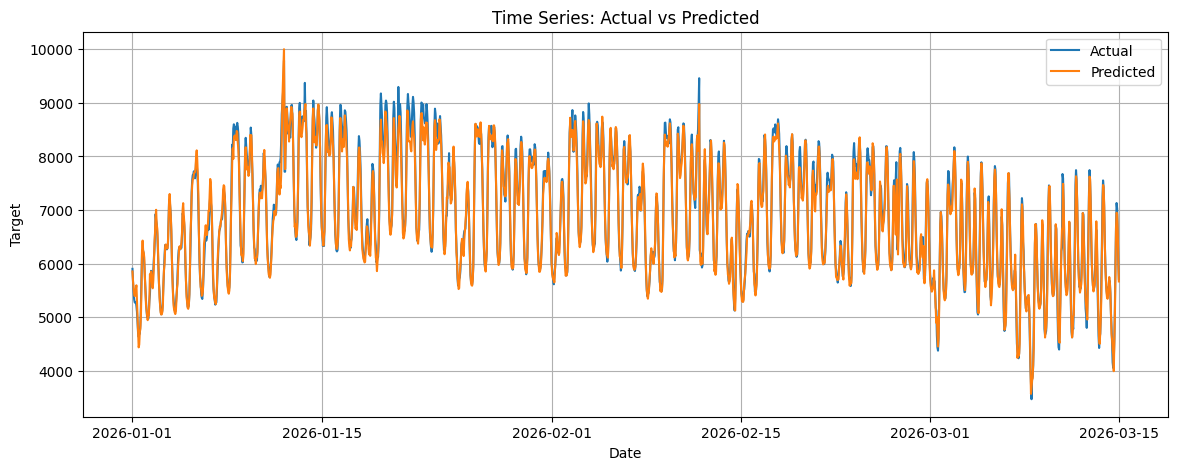

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Target")
plt.title("Time Series: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()